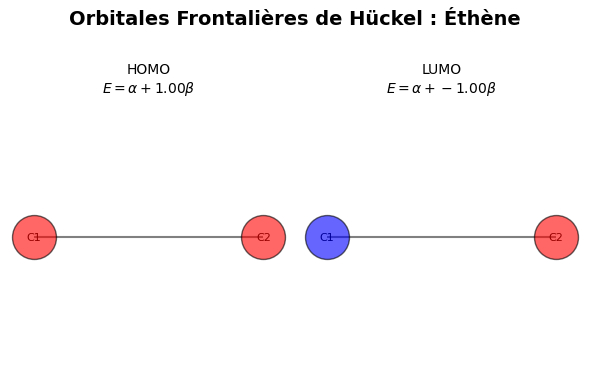

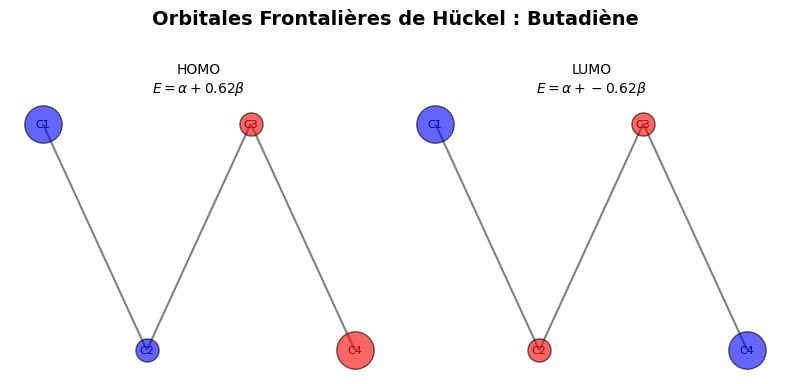

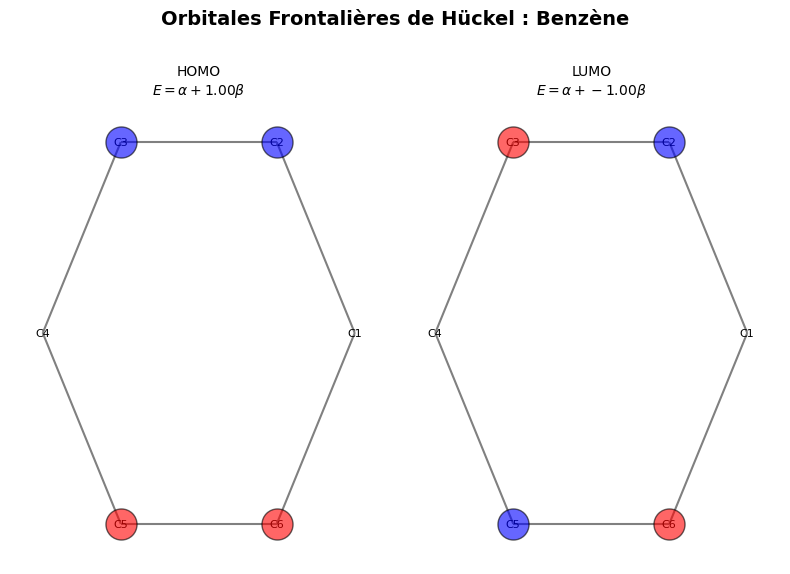

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# --- FONCTION DE CALCUL ---

'''
Dans ce code, dit que S = 1 si voisin sinon recouvrement nul. On ne prends pas en compte longueur de liaison. 

'''

def get_huckel_results(adj_matrix, num_electrons):
    """
    Calcule énergies (valeurs propres x) et coefficients (vecteurs propres).
    Trie les résultats du plus stable (énergie la plus basse) au moins stable.
    Identifie HOMO et LUMO indices.
    """
    # Résolution numérique (retourne valeurs propres triées croissant)
    energies_x, eigenvectors = np.linalg.eigh(adj_matrix)
    
    # Rappel Hückel : E = alpha + x*beta. Beta étant négatif, 
    # l'énergie la plus basse (plus stable) correspond au x le plus GRAND.
    # On trie donc par x décroissant.
    idx_sorted = np.argsort(energies_x)[::-1]
    energies_x = energies_x[idx_sorted]
    coefficients_matrix = eigenvectors[:, idx_sorted] # Matrice (atomes, MOs)

    # Indices HOMO / LUMO (pour orbitales fermées)
    idx_homo = (num_electrons // 2) - 1
    idx_lumo = idx_homo + 1
    
    return energies_x, coefficients_matrix, idx_homo, idx_lumo

# --- FONCTION DE VISUALISATION ---

def plot_molecule_with_mo(ax, G, coords, coeffs, mo_title, energy_x):
    """
    Représente la molécule avec les OM superposées.
    Taille du cercle = |c_i|^2 (densité)
    Couleur = Signe de c_i (Rouge+, Bleu-)
    """
    ax.set_title(f"{mo_title}\n$E = \\alpha + {energy_x:.2f}\\beta$", fontsize=10)
    
    # 1. Dessiner le squelette (liaisons)
    nx.draw_networkx_edges(G, pos=coords, ax=ax, width=1.5, edge_color='gray')
    
    # 2. Dessiner les orbitales p (cercles atomiques)
    # Paramètres d'échelle pour la taille
    base_size = 2000 
    
    # Séparation signes positifs/négatifs
    # On gère les coefficients très proches de zéro pour éviter les erreurs
    threshold = 1e-5
    
    for i, c in enumerate(coeffs):
        x, y = coords[i]
        
        # Taille proportionnelle à la probabilité de présence |c_i|^2
        size = base_size * (c**2) 
        
        if c > threshold:
            color = 'red' # Signe +
            ax.scatter(x, y, s=size, c=color, alpha=0.6, edgecolors='black', zorder=10)
        elif c < -threshold:
            color = 'blue' # Signe -
            ax.scatter(x, y, s=size, c=color, alpha=0.6, edgecolors='black', zorder=10)
        # else: coefficient nul -> pas de cercle
            
    # 3. Ajouter les labels d'atomes (optionnel, mais propre)
    labels = {i: f"C{i+1}" for i in range(len(G.nodes))}
    nx.draw_networkx_labels(G, pos=coords, labels=labels, ax=ax, font_size=8, font_color='black')
    
    ax.axis('off') # Cacher les axes

# ==========================================
# --- DÉFINITION DES DONNÉES ET CALCULS ---
# ==========================================

# Liste des molécules avec leur matrice d'adjacence, coords 2D approximatives, et e-
molecules_data = [
    {
        "name": "Éthène",
        "adj": np.array([[0, 1], [1, 0]]),
        "electrons": 2,
        # Coords (C1, C2)
        "coords": {0: (0, 0), 1: (1, 0)}, 
        "figsize": (6, 4)
    },
    {
        "name": "Butadiène",
        "adj": np.array([[0, 1, 0, 0], [1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0]]),
        "electrons": 4,
        # Coords (C1, C2, C3, C4) zigzag simple
        "coords": {0: (0, 1), 1: (1, 0), 2: (2, 1), 3: (3, 0)}, 
        "figsize": (8, 4)
    },
    {
        "name": "Benzène",
        "adj": np.array([[0, 1, 0, 0, 0, 1], [1, 0, 1, 0, 0, 0], [0, 1, 0, 1, 0, 0], 
                          [0, 0, 1, 0, 1, 0], [0, 0, 0, 1, 0, 1], [1, 0, 0, 0, 1, 0]]),
        "electrons": 6,
        # Coords (C1..C6) hexagone régulier
        "coords": {i: (np.cos(2*np.pi*i/6), np.sin(2*np.pi*i/6)) for i in range(6)},
        "figsize": (8, 6)
    }
]

# =====================================
# --- GÉNÉRATION DES PLOTS ---
# =====================================

for mol in molecules_data:
    name = mol["name"]
    # 1. Calculs de Hückel
    energies, coeffs_matrix, homo_idx, lumo_idx = get_huckel_results(mol["adj"], mol["electrons"])
    
    # 2. Création du graphe NetworkX
    G = nx.from_numpy_array(mol["adj"])
    
    # 3. Création de la figure (1 ligne, 2 colonnes : HOMO et LUMO side-by-side)
    fig, axs = plt.subplots(1, 2, figsize=mol["figsize"])
    fig.suptitle(f"Orbitales Frontalières de Hückel : {name}", fontsize=14, fontweight='bold')
    
    # --- Plot HOMO ---
    plot_molecule_with_mo(axs[0], G, mol["coords"], 
                           coeffs_matrix[:, homo_idx], # Coefficients de la HOMO
                           "HOMO", energies[homo_idx])
    
    # --- Plot LUMO ---
    plot_molecule_with_mo(axs[1], G, mol["coords"], 
                           coeffs_matrix[:, lumo_idx], # Coefficients de la LUMO
                           "LUMO", energies[lumo_idx])
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajuster pour le titre principal
    plt.show()